# Step 1: Gene Prediction Evaluation

This notebook evaluates the structural concordance of gene predictions from various prokaryotic annotation tools (Prokka, Bakta, PGAP, eggNOG) against the NCBI RefSeq ground truth. 

It standardizes the GFF outputs, calculates performance metrics (Precision, Recall, F1-Score), visualizes intersections using UpSet plots, and exports the concordant CDS sets for downstream functional analysis.

In [1]:
import sys
import requests
import os
import pandas as pd
from pathlib import Path
from IPython.display import display

from benchannot.prokaryotic.gene_prediction import (
    clean_prokka_gff,
    load_gff,
    standardize_gff,
    calculate_structural_metrics,
    plot_concordance_upset,
    export_concordant_cds,
)

In [2]:
ORGANISMS = ["bacillus_subtilis", "escherichia_coli"]
TOOLS_TO_EVALUATE = ["Prokka", "Bakta", "PGAP", "eggNOG"]
UPSET_ORDER = ["Reference", "PGAP", "Bakta", "Prokka", "eggNOG"]
PROJECT_ROOT = Path("../../..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
ORIGIN_DIR = DATA_DIR / "origin"
GENOME_PROKARYOTE_DIR = DATA_DIR / "genome_prokaryote"
OUTPUT_DIR = PROJECT_ROOT / "2_run" / "output" / "prokaryotic"

## 1. Process, Evaluate, and Export

Iterate through each organism to clean the Prokka GFF, standardize all tool outputs into a unified format, generate concordance plots, calculate F1 metrics, and export the true positive CDS matches.

  Processing: BACILLUS_SUBTILIS
  Cleaned: /var/locally-mounted/cauim/marymardegan/documents_marymardegan/analysis_benchannot/2_run/output/prokaryotic/bacillus_subtilis_prokka_cleaned.gff


/home/marymardegan/miniconda3/envs/upset_env/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/marymardegan/miniconda3/envs/upset_env/lib/python3.10/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on

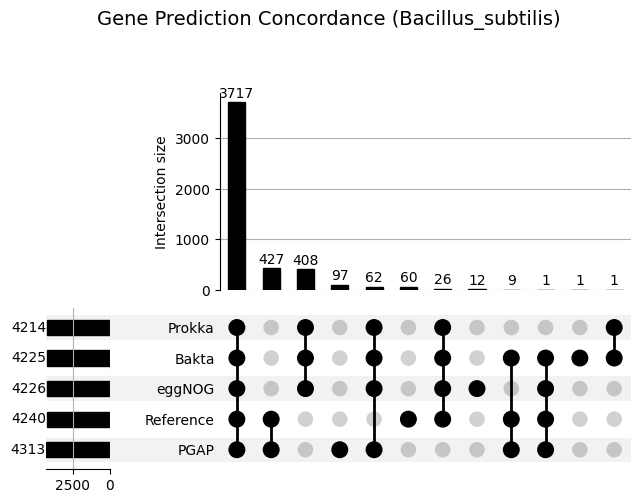

Metrics (Bacillus_subtilis)


,Annotation Tool,Exact Matches (TP),Spurious/Shifted (FP),Missed Genes (FN),Precision,Recall,F1-Score
0,PGAP,4154,159,86,0.963100,0.979700,0.971400
1,Bakta,3753,472,487,0.888300,0.885100,0.886700
2,Prokka,3743,471,497,0.888200,0.882800,0.885500
3,eggNOG,3744,482,496,0.885900,0.883000,0.884500


  Exporting concordant CDS records to /var/locally-mounted/cauim/marymardegan/documents_marymardegan/analysis_benchannot/2_run/output/prokaryotic/bacillus_subtilis_concordant_CDS.csv
-> Exported 3717 concordant CDS records to /var/locally-mounted/cauim/marymardegan/documents_marymardegan/analysis_benchannot/2_run/output/prokaryotic/bacillus_subtilis_concordant_CDS.csv
  Processing: ESCHERICHIA_COLI
  Cleaned: /var/locally-mounted/cauim/marymardegan/documents_marymardegan/analysis_benchannot/2_run/output/prokaryotic/escherichia_coli_prokka_cleaned.gff


/home/marymardegan/miniconda3/envs/upset_env/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/marymardegan/miniconda3/envs/upset_env/lib/python3.10/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on

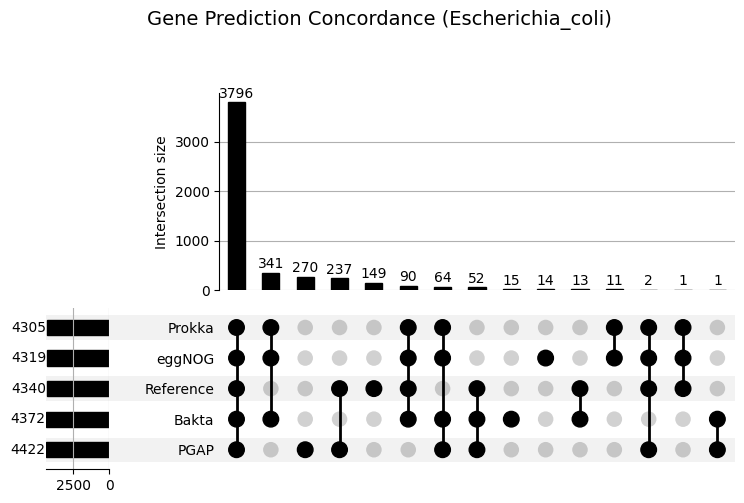

Metrics (Escherichia_coli)


,Annotation Tool,Exact Matches (TP),Spurious/Shifted (FP),Missed Genes (FN),Precision,Recall,F1-Score
0,PGAP,4087,335,253,0.924200,0.941700,0.932900
1,Bakta,3951,421,389,0.903700,0.910400,0.907000
2,Prokka,3889,416,451,0.903400,0.896100,0.899700
3,eggNOG,3889,430,451,0.900400,0.896100,0.898300


  Exporting concordant CDS records to /var/locally-mounted/cauim/marymardegan/documents_marymardegan/analysis_benchannot/2_run/output/prokaryotic/escherichia_coli_concordant_CDS.csv
-> Exported 3796 concordant CDS records to /var/locally-mounted/cauim/marymardegan/documents_marymardegan/analysis_benchannot/2_run/output/prokaryotic/escherichia_coli_concordant_CDS.csv


In [3]:
all_metrics = {}

for org in ORGANISMS:
    print(f"  Processing: {org.upper()}")

    PROKKA_RAW = (ORIGIN_DIR/"prokaryote_output_tools"/"prokka"/f"{org}.gff")
    PROKKA_CLEAN = (OUTPUT_DIR/f"{org}_prokka_cleaned.gff")
    PGAP_RAW = (ORIGIN_DIR/"prokaryote_output_tools"/"pgap"/f"{org}_annot.gff")
    BAKTA_RAW = (ORIGIN_DIR/"prokaryote_output_tools"/"bakta"/f"{org}.gff3")
    EGGNOG_RAW = (ORIGIN_DIR/"prokaryote_output_tools"/"eggnog"/f"{org}.emapper.decorated.gff")
    GENBANK_PATH = (GENOME_PROKARYOTE_DIR/f"{org}.gff")
    EXPORT_CSV = (OUTPUT_DIR/f"{org}_concordant_CDS.csv")

    clean_prokka_gff(PROKKA_RAW, PROKKA_CLEAN)
    print(f"  Cleaned: {PROKKA_CLEAN}")

    dfs = [
        load_gff(EGGNOG_RAW, "eggNOG"),
        load_gff(BAKTA_RAW, "Bakta"),
        load_gff(PROKKA_CLEAN, "Prokka"),
        load_gff(PGAP_RAW, "PGAP"),
        load_gff(GENBANK_PATH, "Reference"),
    ]

    standardized_dfs = []
    for df in dfs:
        if df["Source"].iloc[0] == "eggNOG":
            standardized_dfs.append(standardize_gff(df, is_eggnog=True))
        else:
            standardized_dfs.append(standardize_gff(df))

    all_gffs = pd.concat(standardized_dfs, ignore_index=True)

    plot_concordance_upset(
        all_gffs_df=all_gffs,
        tools_order=UPSET_ORDER,
        title=f"Gene Prediction Concordance ({org.capitalize()})",
        save_path=f"{OUTPUT_DIR}/{org}_gene_prediction.png",
    )

    print(f"Metrics ({org.capitalize()})")
    df_metrics = calculate_structural_metrics(all_gffs, tools=TOOLS_TO_EVALUATE)

    all_metrics[org] = df_metrics

    display(
        df_metrics.style.background_gradient(
            cmap="Blues", subset=["F1-Score", "Precision", "Recall"]
        )
    )

    print(f"  Exporting concordant CDS records to {EXPORT_CSV}")

    tp_df = export_concordant_cds(all_gffs, TOOLS_TO_EVALUATE, "Reference", EXPORT_CSV)
    print(f"-> Exported {len(tp_df)} concordant CDS records to {EXPORT_CSV}")